# Information Theory Project — Part 1
## Text Source: Token-Level Analysis (GPT-2 BPE Tokenizer)


In [2]:
import math
import collections
import matplotlib.pyplot as plt

# Load the tokenizer — GPT-2 BPE
# Install if needed: pip install transformers
from transformers import GPT2TokenizerFast
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

# Load the same text file used in text.ipynb
with open('Text.txt', 'r', encoding='utf-8') as f:
    raw = f.read()

# Tokenize: convert text to a sequence of token IDs
tokens = tokenizer.encode(raw)

print(f'Total characters: {len(raw)}')
print(f'Total tokens: {len(tokens)}')
print(f'Avg characters per token: {len(raw)/len(tokens):.2f}')
print(f'Vocabulary size (nominal): {tokenizer.vocab_size}')
print(f'Distinct tokens observed: {len(set(tokens))}')

Token indices sequence length is longer than the specified maximum sequence length for this model (42596 > 1024). Running this sequence through the model will result in indexing errors


Total characters: 201276
Total tokens: 42596
Avg characters per token: 4.73
Vocabulary size (nominal): 50257
Distinct tokens observed: 680


---
## Task 1 — Single-Symbol Entropy
### Q1a: Empirical token distribution

Top 10 most frequent tokens:
  ID=   11 | "," | P=0.0675
  ID=  262 | " the" | P=0.0604
  ID=  286 | " of" | P=0.0410
  ID=   13 | "." | P=0.0403
  ID=  257 | " a" | P=0.0398
  ID=  318 | " is" | P=0.0271
  ID=  198 | "
" | P=0.0235
  ID=  383 | " The" | P=0.0124
  ID=  290 | " and" | P=0.0119
  ID=  284 | " to" | P=0.0118


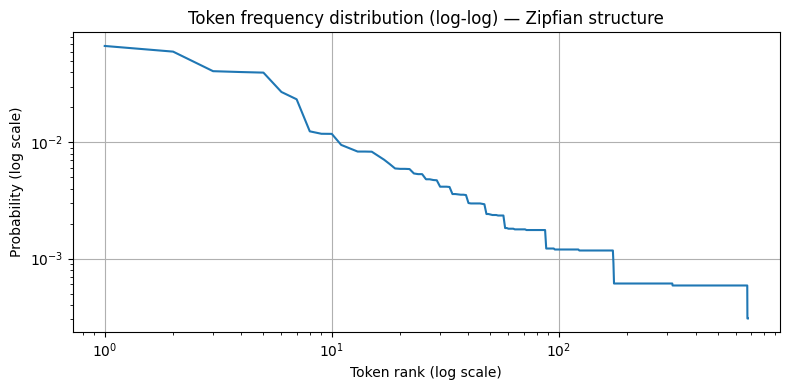

In [3]:
n = len(tokens)
counts = collections.Counter(tokens)
probs = {x: c/n for x,c in counts.items()}

# Top 10 most frequent tokens
print('Top 10 most frequent tokens:')
for tok_id, p in sorted(probs.items(), key=lambda x: -x[1])[:10]:
    tok_str = tokenizer.decode([tok_id])
    print(f'  ID={tok_id:5d} | "{tok_str}" | P={p:.4f}')

# Token frequency distribution is very skewed (Zipfian)
sorted_probs = sorted(probs.values(), reverse=True)
plt.figure(figsize=(8,4))
plt.loglog(range(1, len(sorted_probs)+1), sorted_probs)
plt.xlabel('Token rank (log scale)')
plt.ylabel('Probability (log scale)')
plt.title('Token frequency distribution (log-log) — Zipfian structure')
plt.grid(True)
plt.tight_layout()
plt.savefig('token_distribution.png', dpi=100)
plt.show()

### Q1b: Plug-in entropy estimate

In [4]:
def entropy(prob_dict):
    return -sum(p*math.log2(p) for p in prob_dict.values() if p > 0)

H_token = entropy(probs)
k_obs = len(probs)
H_max = math.log2(k_obs)

print(f'Plug-in entropy (tokens):        {H_token:.4f} bits/token')
print(f'Distinct tokens observed:        {k_obs}')
print(f'Maximum entropy (uniform over k): {H_max:.4f} bits')
print(f'Ratio H/H_max:                    {H_token/H_max:.4f}')

# Convert to bits per character for fair comparison with char-level
avg_chars_per_token = len(raw) / len(tokens)
H_token_per_char = H_token / avg_chars_per_token
print(f'\nFor comparison with character-level:')
print(f'H = {H_token:.4f} bits/token = {H_token_per_char:.4f} bits/character')

Plug-in entropy (tokens):        7.8656 bits/token
Distinct tokens observed:        680
Maximum entropy (uniform over k): 9.4094 bits
Ratio H/H_max:                    0.8359

For comparison with character-level:
H = 7.8656 bits/token = 1.6646 bits/character


### Q1c: Entropy vs sample size — tokens need more data!

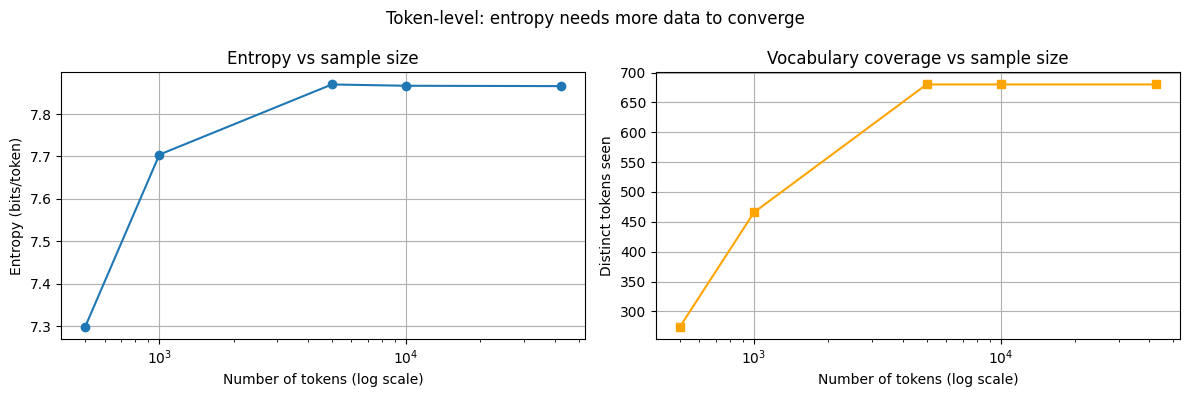

Token entropy takes much longer to converge — large alphabet + rare tokens.


In [5]:
sample_sizes = [s for s in [500, 1000, 5000, 10000, 50000, len(tokens)] if s <= len(tokens)]
H_vs_n = []
k_vs_n = []  # number of distinct tokens seen

for n_s in sample_sizes:
    sub = tokens[:n_s]
    c = collections.Counter(sub)
    p = {x: v/n_s for x,v in c.items()}
    H_vs_n.append(entropy(p))
    k_vs_n.append(len(c))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(sample_sizes, H_vs_n, marker='o')
axes[0].set_xlabel('Number of tokens (log scale)')
axes[0].set_ylabel('Entropy (bits/token)')
axes[0].set_title('Entropy vs sample size')
axes[0].grid(True)

axes[1].semilogx(sample_sizes, k_vs_n, marker='s', color='orange')
axes[1].set_xlabel('Number of tokens (log scale)')
axes[1].set_ylabel('Distinct tokens seen')
axes[1].set_title('Vocabulary coverage vs sample size')
axes[1].grid(True)

plt.suptitle('Token-level: entropy needs more data to converge')
plt.tight_layout()
plt.savefig('token_entropy_vs_n.png', dpi=100)
plt.show()
print('Token entropy takes much longer to converge — large alphabet + rare tokens.')

### Q1d: Miller-Madow bias correction

In [6]:
def entropy_mm(sym_list):
    n = len(sym_list)
    c = collections.Counter(sym_list)
    k = len(c)
    p = {x: v/n for x,v in c.items()}
    return entropy(p) + (k-1)/(2*n*math.log(2))

print('Token-level — plug-in vs Miller-Madow:')
for n_s in [1000, 5000, 10000, len(tokens)]:
    if n_s > len(tokens): continue
    sub = tokens[:n_s]
    c = collections.Counter(sub)
    p = {x: v/n_s for x,v in c.items()}
    h_p  = entropy(p)
    h_mm = entropy_mm(sub)
    print(f'  n={n_s:7d}: plug-in={h_p:.4f}, MM={h_mm:.4f}, correction={h_mm-h_p:.4f}')

print()
print('The correction is much larger for tokens than for characters.')
print('Reason: alphabet size k is large, so (k-1)/(2n) is significant at small n.')

Token-level — plug-in vs Miller-Madow:
  n=   1000: plug-in=7.7044, MM=8.0398, correction=0.3354
  n=   5000: plug-in=7.8696, MM=7.9675, correction=0.0980
  n=  10000: plug-in=7.8665, MM=7.9155, correction=0.0490
  n=  42596: plug-in=7.8656, MM=7.8771, correction=0.0115

The correction is much larger for tokens than for characters.
Reason: alphabet size k is large, so (k-1)/(2n) is significant at small n.


---
## Task 2 — Joint and Conditional Entropy
### Q2a: Joint entropy H(Xt-1, Xt) at token level

In [7]:
H_plugin = entropy(probs)

pairs = [(tokens[i], tokens[i+1]) for i in range(len(tokens)-1)]
n_pairs = len(pairs)
pair_counts = collections.Counter(pairs)
pair_probs = {p: c/n_pairs for p,c in pair_counts.items()}

H_joint = entropy(pair_probs)
print(f'H(X) token          = {H_plugin:.4f} bits/token')
print(f'H(Xt-1, Xt) token   = {H_joint:.4f} bits')
print(f'2*H(X) (i.i.d.)     = {2*H_plugin:.4f} bits')
print(f'I(Xt-1;Xt)          = {2*H_plugin-H_joint:.4f} bits')

H(X) token          = 7.8656 bits/token
H(Xt-1, Xt) token   = 10.1738 bits
2*H(X) (i.i.d.)     = 15.7313 bits
I(Xt-1;Xt)          = 5.5575 bits


### Q2b: Conditional entropy H(Xt | Xt-1)

In [8]:
H_cond = H_joint - H_plugin
print(f'H(Xt | Xt-1) = {H_cond:.4f} bits/token')
print(f'Reduction from H(X): {H_plugin - H_cond:.4f} bits/token')
print()

# Convert to bits per character for comparison
avg_cpt = len(raw) / len(tokens)
print(f'In bits/character: H(X)={H_plugin/avg_cpt:.4f}, H(Xt|Xt-1)={H_cond/avg_cpt:.4f}')
if H_cond < H_plugin:
    print('Strong token-level dependencies — consecutive tokens are not independent.')

H(Xt | Xt-1) = 2.3082 bits/token
Reduction from H(X): 5.5575 bits/token

In bits/character: H(X)=1.6646, H(Xt|Xt-1)=0.4885
Strong token-level dependencies — consecutive tokens are not independent.


### Q2c: Finite-sample bias for token-level joint entropy

In [9]:
k = len(probs)  # number of observed token types

bias_marginal = (k - 1) / (2 * len(tokens) * math.log(2))
bias_joint    = (k*k - 1) / (2 * n_pairs * math.log(2))

print(f'Distinct token types k = {k}')
print(f'Estimated bias of H(X) estimator:         {bias_marginal:.4f} bits')
print(f'Estimated bias of H(Xt-1,Xt) estimator:   {bias_joint:.4f} bits')
print()
print('With a large token alphabet, the joint estimator bias can be substantial.')
print('This is why token-level analysis needs much more data than character-level.')

Distinct token types k = 680
Estimated bias of H(X) estimator:         0.0115 bits
Estimated bias of H(Xt-1,Xt) estimator:   7.8307 bits

With a large token alphabet, the joint estimator bias can be substantial.
This is why token-level analysis needs much more data than character-level.


---
## Task 3 — Entropy Rate Estimation
### Q3a: Block-entropy method

In [10]:
def block_entropy_rate(seq, block_len):
    blocks = [tuple(seq[i:i+block_len]) for i in range(0, len(seq)-block_len+1, block_len)]
    if len(blocks) < 10: return None
    c = collections.Counter(blocks)
    p = {b: v/len(blocks) for b,v in c.items()}
    return entropy(p) / block_len

print('Block-entropy method (token level):')
block_results = []
for bl in [1, 2, 3]:
    hr = block_entropy_rate(tokens, bl)
    if hr:
        block_results.append((bl, hr))
        print(f'  Block {bl}: {hr:.4f} bits/token = {hr/avg_cpt:.4f} bits/char')

Block-entropy method (token level):
  Block 1: 7.8656 bits/token = 1.6646 bits/char
  Block 2: 4.6787 bits/token = 0.9902 bits/char
  Block 3: 3.3445 bits/token = 0.7078 bits/char


### Q3b: Conditional-entropy method

In [11]:
def cond_entropy_rate(seq, k):
    ctx_next = collections.Counter()
    ctx_cnt  = collections.Counter()
    for i in range(k, len(seq)):
        ctx = tuple(seq[i-k:i])
        ctx_next[(ctx, seq[i])] += 1
        ctx_cnt[ctx] += 1
    total = sum(ctx_cnt.values())
    H = 0.0
    for ctx, cnt in ctx_cnt.items():
        p_ctx = cnt / total
        h_c = 0.0
        for sym, freq in collections.Counter(
            [nxt for (c,nxt),v in ctx_next.items() if c == ctx]
        ).items():
            p = freq / cnt
            h_c -= p * math.log2(p)
        H += p_ctx * h_c
    return H

print('Conditional-entropy method (token level):')
cond_results = [(0, H_plugin)]
print(f'  Context 0: {H_plugin:.4f} bits/token')
for k in [1, 2]:
    hr = cond_entropy_rate(tokens, k)
    cond_results.append((k, hr))
    print(f'  Context {k}: {hr:.4f} bits/token = {hr/avg_cpt:.4f} bits/char')

Conditional-entropy method (token level):
  Context 0: 7.8656 bits/token
  Context 1: 0.2287 bits/token = 0.0484 bits/char
  Context 2: 0.1929 bits/token = 0.0408 bits/char


### Q3c: Plot results and compare with character-level

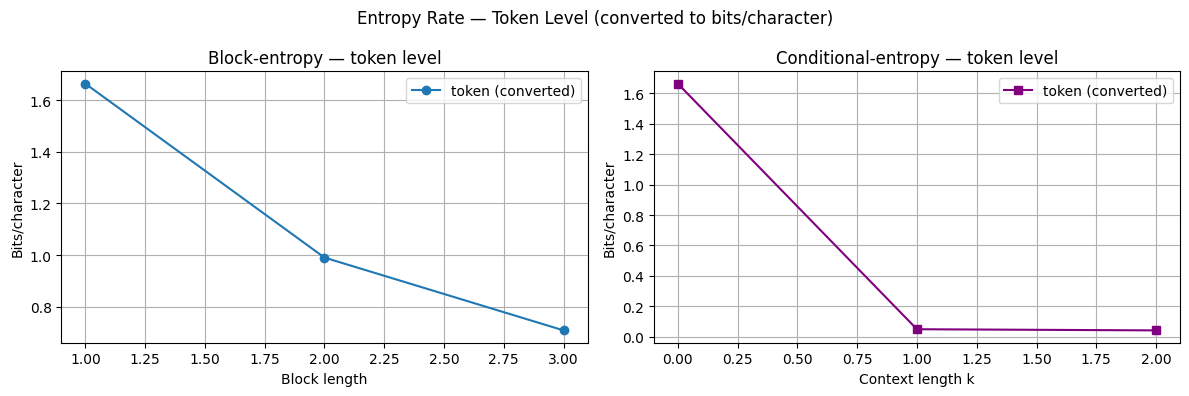

Compare these values (bits/char) with those from text.ipynb.
Token-level entropy rate should be lower — tokens capture more structure.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot([x[0] for x in block_results], [x[1]/avg_cpt for x in block_results],
             marker='o', label='token (converted)')
axes[0].set_xlabel('Block length')
axes[0].set_ylabel('Bits/character')
axes[0].set_title('Block-entropy — token level')
axes[0].legend()
axes[0].grid(True)

axes[1].plot([x[0] for x in cond_results], [x[1]/avg_cpt for x in cond_results],
             marker='s', color='purple', label='token (converted)')
axes[1].set_xlabel('Context length k')
axes[1].set_ylabel('Bits/character')
axes[1].set_title('Conditional-entropy — token level')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Entropy Rate — Token Level (converted to bits/character)')
plt.tight_layout()
plt.savefig('token_entropy_rate.png', dpi=100)
plt.show()

print('Compare these values (bits/char) with those from text.ipynb.')
print('Token-level entropy rate should be lower — tokens capture more structure.')